In [9]:


%pip install pandas
import pandas as pd

df = pd.read_csv('Unemployment in India.csv')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
%matplotlib inline

In [18]:

df = pd.read_csv('Unemployment in India.csv')

X = unemployment.data
y = unemployment.target

df = pd.DataFrame(X, columns=unemployment.feature_names)
df['species'] = [unemployment.target_names[i] for i in y]

print("Shape of dataset:", df.shape)
df.head()

NameError: name 'unemployment' is not defined

In [19]:
import pandas as pd

# Load the unemployment dataset
df = pd.read_csv('Unemployment in India.csv')

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from text columns
for col in ['Region', 'Date', 'Frequency', 'Area']:
    df[col] = df[col].astype(str).str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Rename columns for easier use
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

# Display dataset information
print("Shape of dataset:", df.shape)

# Display first 5 rows
df.head()

Shape of dataset: (768, 7)


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [20]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64


In [21]:
df = df.dropna(how='all')

print("Shape after removing blank rows:", df.shape)

Shape after removing blank rows: (740, 7)


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [24]:
print(df.dtypes)

Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object


In [25]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [26]:
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [27]:
df.tail()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban
753,West Bengal,2020-06-30,Monthly,9.86,9088931.0,37.57,Urban


In [28]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (740, 7)

Column Names:
['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area']

Data Types:
Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object


In [29]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64


In [30]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [31]:
state_unemployment = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
)

print(state_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment_Rate, dtype: float64


In [32]:
state_unemployment.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64

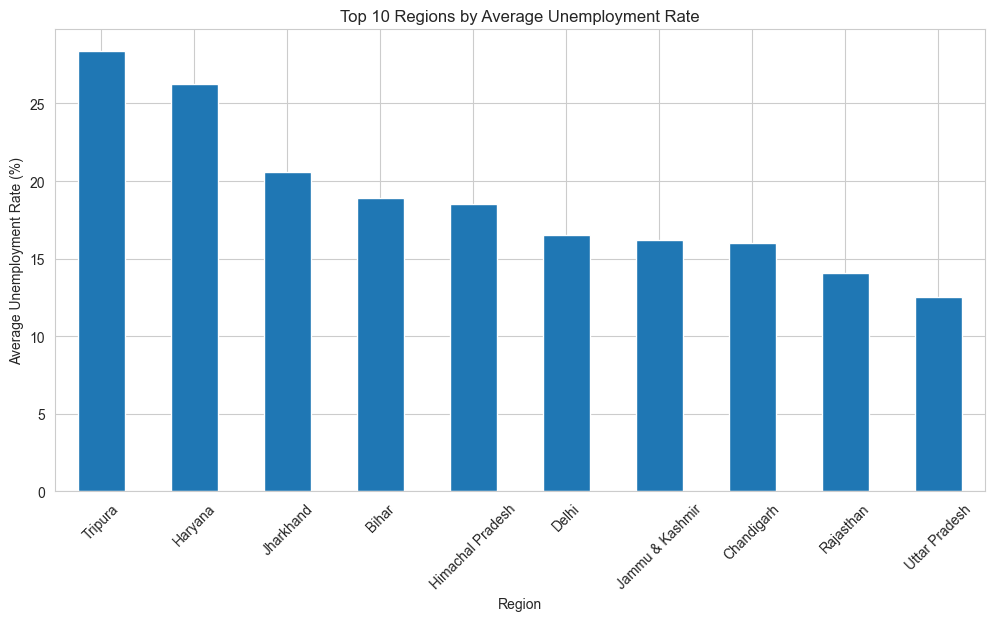

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

state_unemployment.head(10).plot(kind='bar')

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [34]:
area_unemployment = (
    df.groupby('Area')['Unemployment_Rate']
    .mean()
)

print(area_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64


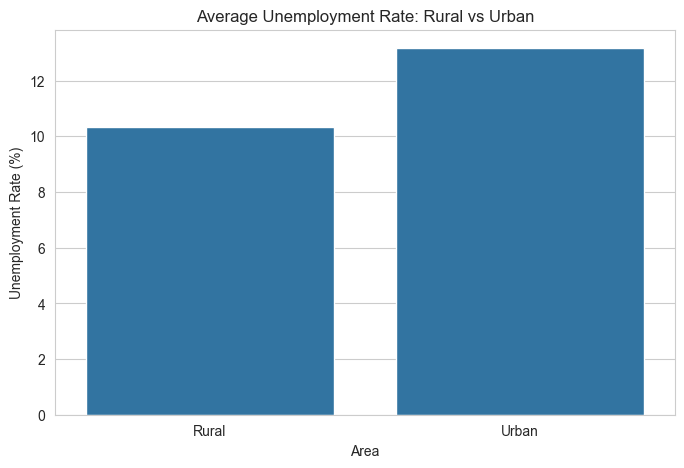

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=area_unemployment.index,
    y=area_unemployment.values
)

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.show()

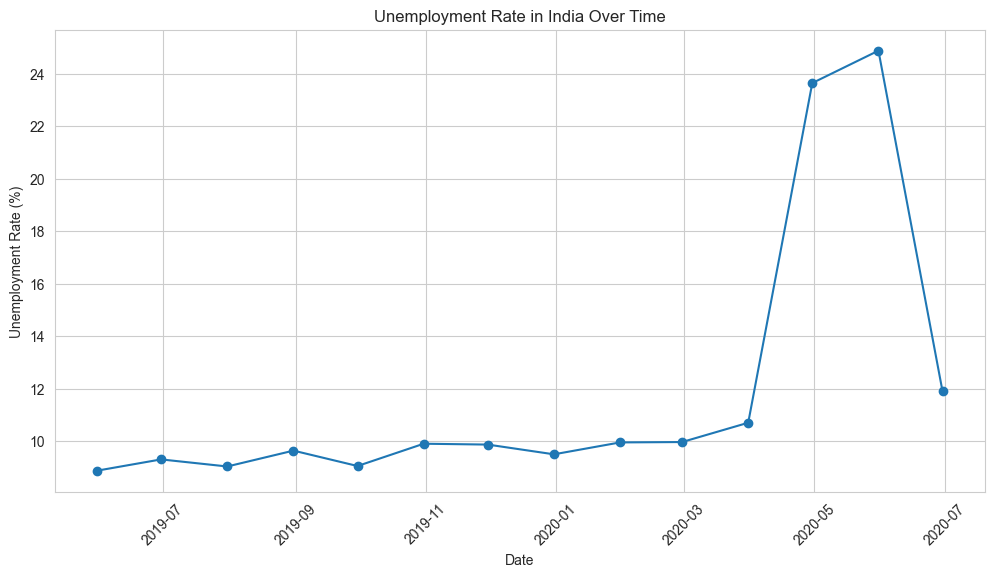

In [36]:
monthly_trend = (
    df.groupby('Date')['Unemployment_Rate']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_trend['Date'],
    monthly_trend['Unemployment_Rate'],
    marker='o'
)

plt.title('Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()